In [4]:
import pandas as pd #ucitava pandas bazu - rad sa podacima u tabelama
import seaborn as sns #crtanje statistickog grafika, heatmap, histrogrami, specijalizovan za naucnu vizuelizaciju
import matplotlib.pyplot as plt #osnovna biblioteka za crtanje

df = pd.read_csv(r"C:\Users\ilija\rubiscodms\41586_2024_8455_MOESM4_ESM.csv")
print("Dataset ucitan, redova:", len(df))

Dataset ucitan, redova: 8760


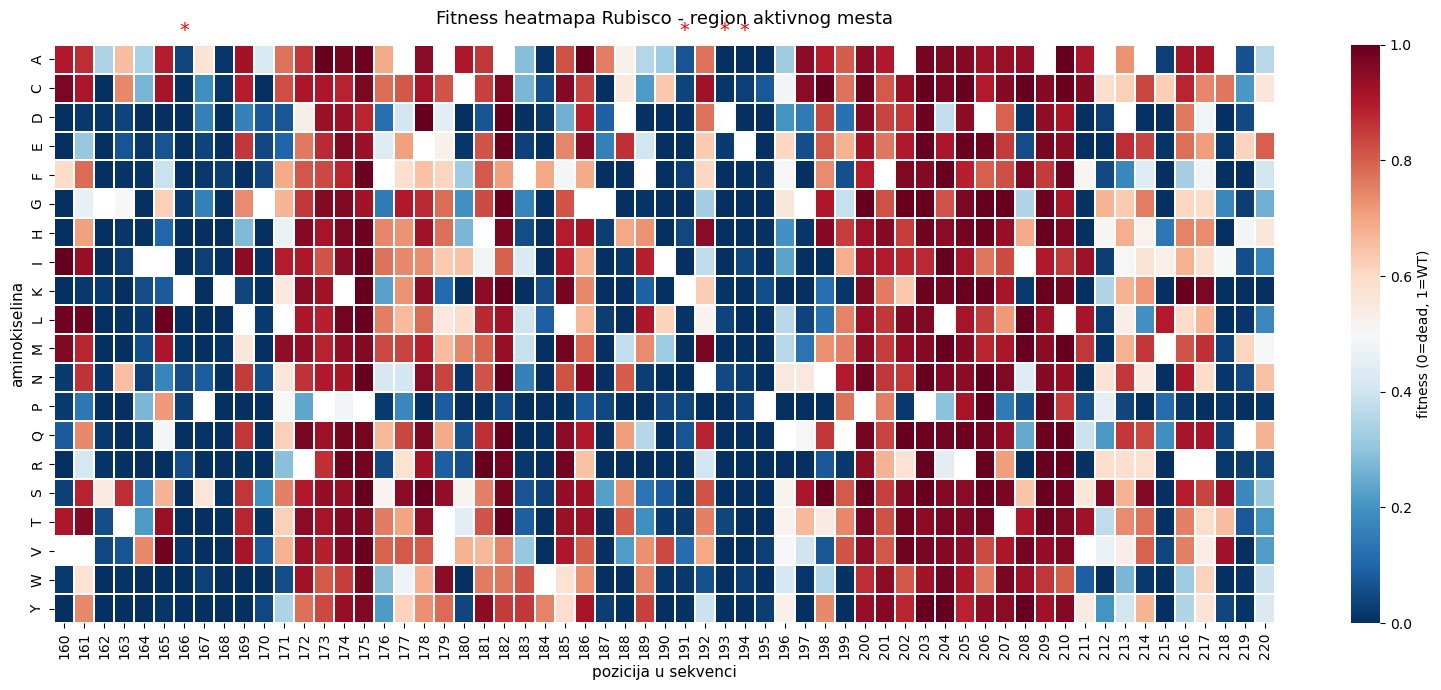

In [12]:
aktivno_mesto = [166, 191, 193, 194, 287, 329] #prave pozicije iz Prywes et al

pivot = df .pivot_table(
    index ='residue',
    columns ='position',
    values ='Fitness'
)                           #redovi aminokiselina, kolone su pozicije

pivot_region = pivot.loc[:, 160:220]

fig, ax = plt.subplots(figsize=(16, 7))

sns.heatmap(
    pivot_region,
    cmap='RdBu_r',
    vmin=0, vmax=1,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'fitness (0=dead, 1=WT)'},
    ax=ax
)
for pos in aktivno_mesto:
    if pos in pivot_region.columns:
        col_idx = list(pivot_region.columns).index(pos)
        ax.annotate('*', xy=(col_idx + 0.5, -0.3),
                    color='red',
                    ha='center', fontsize=14,
                    annotation_clip=False)
ax.set_title("Fitness heatmapa Rubisco - region aktivnog mesta", fontsize=13, pad=15)
ax.set_xlabel("pozicija u sekvenci", fontsize=11)
ax.set_ylabel("aminokiselina", fontsize=11)

plt.tight_layout()
plt.savefig("heatmapa_finalna.png", dpi=200)
plt.show()

